## Medical AI
## Skin Lesion Analysis - Towards Melanoma Detection

Skin cancer is the most common cancer globally, with melanoma being the most deadly form. Dermoscopy is a skin imaging modality that has demonstrated improvement for diagnosis of skin cancer compared to unaided visual inspection. However, clinicians should receive adequate training for those improvements to be realized. In order to make expertise more widely available, the International Skin Imaging Collaboration (ISIC) has developed the ISIC Archive, an international repository of dermoscopic images, for both the purposes of clinical training, and for supporting technical research toward automated algorithmic analysis by hosting the ISIC Challenges.



## Preparing the Environment

In [ ]:
#FIXME throughout the notebook search for this tag for things to pay attention to

First, add the dataset that we prepared as input. This prepared dataset is small enough for fast loading, and large enough for good performance.

Click Add Input, and enter this link: https://www.kaggle.com/datasets/matthancaan/medicalai

In [1]:
#!pip install pytorch-lightning
#!pip install wandb
from google.colab import drive #for google colab

import os
import glob
import numpy as np
import nibabel as nib
from scipy.ndimage import rotate
import matplotlib.pyplot as plt
import torch
import torchvision
import torchmetrics
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import pytorch_lightning as pl
import wandb
from pytorch_lightning.loggers import WandbLogger
import cv2

SEED=42

torch.backends.cudnn.deterministic = True
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
np.random.RandomState(SEED)
pl.seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Seed set to 42


In [2]:
# log in to Weights & Biases (will prompt for your API key: https://wandb.ai/authorize)
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: thiagosfam (group12-melanoma-detection) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Classification

In [3]:
# FIXME set your data directory here
#data_dir = '/kaggle/input/datasets/matthancaan/medicalai/classification/'
data_dir = '/kaggle/input/datasets/matthancaan/medical-ai-with-test-set/classification/'

### Preprocessing

In [59]:
def remove_hair(image):
    """image: HWC numpy array, uint8, RGB"""
    img = np.uint8(image)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # blackhat: highlights dark, thin structures (hair) against lighter background
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    
    # threshold to get a binary mask of hair pixels
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    
    # inpaint: fill hair pixels using surrounding texture
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    
    return inpainted, hair_mask

### Data Modules

In [6]:
class Scan_Dataset(Dataset):
    def __init__(self, data_dir, transform=False, remove_hair_preprocessing=False):
      self.transform = transform
      self.remove_hair_preprocessing = remove_hair_preprocessing  
      self.data_list = sorted(glob.glob(os.path.join(data_dir,'img*.nii')))

    def __len__(self):
      """defines the size of the dataset (equal to the length of the data_list)"""
      return len(self.data_list)

    def __getitem__(self, idx):
      """ensures each item in data_list is randomly and uniquely assigned an index (idx) so it can be loaded"""
      if torch.is_tensor(idx):
        idx = idx.tolist()

      # loading image
      image_name = self.data_list[idx]
      image = nib.load(image_name).get_fdata()

      if self.remove_hair_preprocessing:
          image, _ = remove_hair(np.uint8(image))  # deterministic, applied to EVERY image
      
      
      # setting label from image name
      label = int(image_name.split('.')[0][-1])
      label = torch.tensor(label)

      # apply transforms
      if self.transform:
        image = self.transform(image)

      return image, label

###Visualizing the data

Visualize patients image and labels (cancer or not).

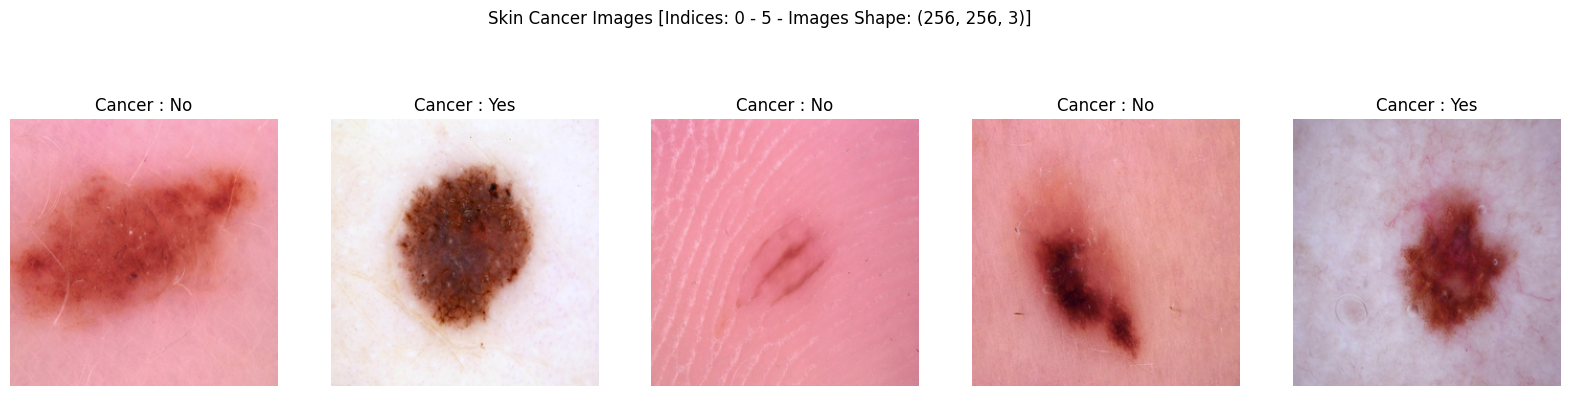

In [7]:
#@title Visualizing Images { run: 'auto'}
nn_set = 'train' #@param ['train', 'val', 'test']
index  = 0 #@param {type:'slider', min:0, max:355, step:5}

dataset  = Scan_Dataset(os.path.join(data_dir, nn_set))
n_images_display = 5
fig, ax = plt.subplots(1, n_images_display, figsize=(20, 5))
for i in range(n_images_display):
  image, label = dataset[index+i]
  ax[i].imshow(np.uint8(image))
  #ax[i].imshow(np.uint8(np.transpose(image, (1, 2, 0))));
  ax[i].set_title(f'Cancer : {"Yes" if label else "No"}')
  ax[i].axis('off')
plt.suptitle(f'Skin Cancer Images [Indices: {index} - {index + n_images_display} - Images Shape: {dataset[0][0].shape}]');

### Data Augmentation

In [8]:
def random_flip_rotate(image):
    if np.random.rand() < 0.5:
        image = np.fliplr(image).copy()
    if np.random.rand() < 0.5:
        image = np.flipud(image).copy()
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-20, 20)
        image = rotate(image, angle, axes=(0, 1), reshape=False, mode='reflect')
    return image

In [9]:
def add_synthetic_hair(image, n_hairs=None):
    """image: HWC numpy array, uint8"""
    img = image.copy()
    h, w = img.shape[:2]
    
    if n_hairs is None:
        n_hairs = np.random.randint(3, 8)
    
    for _ in range(n_hairs):
        x1, y1 = np.random.randint(0, w), np.random.randint(0, h)
        x2, y2 = x1 + np.random.randint(-60, 60), y1 + np.random.randint(-60, 60)
        color = np.random.randint(0, 60)
        thickness = np.random.randint(1, 2)
        cv2.line(img, (x1, y1), (x2, y2), (color, color, color), thickness, lineType=cv2.LINE_AA)
    
    return img

In [10]:
class Random_Transform(object):
  """Transform ndarrays in sample."""
  def __init__(self, probability):
    assert isinstance(probability, float) and 0 < probability <= 1, 'Probability must be a float number between 0 and 1'
    self.probability = probability

  def __call__(self, sample):
    if float(torch.rand(1, dtype=torch.float64)) < self.probability:
        sample = add_synthetic_hair(np.uint8(sample))
    return sample.copy()

### Data Loader

In [11]:
class Scan_DataModule(pl.LightningDataModule):
  def __init__(self, config):
    super().__init__()
    self.config = config  # store for use in setup()
    self.train_data_dir   = config['train_data_dir']
    self.val_data_dir     = config['val_data_dir']
    self.test_data_dir    = config['test_data_dir']
    self.batch_size       = config['batch_size']

    to_tensor = transforms.Lambda(lambda x: torch.from_numpy(x).permute(2, 0, 1).float() / 255.0)
    hair_prob = config.get('hair_prob', 0.1)

    if config.get('pretrained_normalization', False):
        normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.train_transforms = transforms.Compose([Random_Transform(hair_prob), 
                                                    transforms.Lambda(random_flip_rotate), 
                                                    to_tensor, 
                                                    normalize])
        self.val_transforms   = transforms.Compose([to_tensor, normalize])
    else:
        self.train_transforms = transforms.Compose([Random_Transform(hair_prob),
                                                    transforms.Lambda(random_flip_rotate),
                                                    to_tensor])
        self.val_transforms   = transforms.Compose([to_tensor])

  def setup(self, stage=None):
    remove_hair_flag = self.config.get('remove_hair_preprocessing', False)  
    self.train_dataset = Scan_Dataset(self.train_data_dir, transform = self.train_transforms)
    self.val_dataset   = Scan_Dataset(self.val_data_dir  , transform = self.val_transforms)
    self.test_dataset  = Scan_Dataset(self.test_data_dir  , transform = self.val_transforms)

  def train_dataloader(self):
    return DataLoader(self.train_dataset, batch_size = self.batch_size, num_workers=3)

  def val_dataloader(self):
    return DataLoader(self.val_dataset, batch_size = self.batch_size, num_workers=3)

  def test_dataloader(self):
    return DataLoader(self.test_dataset, batch_size = self.batch_size, num_workers=3)

## Dataset Statistics

In [12]:
from collections import Counter

data_dir = '/kaggle/input/datasets/matthancaan/medicalai/classification/'

for split in ['train', 'val', 'test']:
    split_path = os.path.join(data_dir, split)
    files = sorted(glob.glob(os.path.join(split_path, 'img*.nii')))
    
    if not files:
        print(f"{split}: no matching files found at {split_path}")
        continue
    
    labels = [int(f.split('.')[0][-1]) for f in files]
    counts = Counter(labels)
    total = len(labels)
    
    print(f"\n{split}: {total} samples")
    for label, count in sorted(counts.items()):
        pct = 100 * count / total
        tag = "Cancer" if label == 1 else "No cancer"
        print(f"  label {label} ({tag}): {count} ({pct:.1f}%)")
    
    if len(counts) == 2:
        ratio = max(counts.values()) / min(counts.values())
        print(f"  imbalance ratio: {ratio:.2f}:1")


train: 1000 samples
  label 0 (No cancer): 500 (50.0%)
  label 1 (Cancer): 500 (50.0%)
  imbalance ratio: 1.00:1

val: 400 samples
  label 0 (No cancer): 198 (49.5%)
  label 1 (Cancer): 202 (50.5%)
  imbalance ratio: 1.02:1
test: no matching files found at /kaggle/input/datasets/matthancaan/medicalai/classification/test


### CNN - Models

Below you have space for implementing you own architecture and optimizing it the way you want.
A first model is given.

In [13]:
#FIXME add your models here

class SimpleConvNet(pl.LightningModule):

  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
        # conv block 1
        nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1),
        nn.BatchNorm2d(8),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        # conv block 2
        nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(2,2))

    self.classifier = nn.Sequential(
        # linear layers
        nn.AdaptiveAvgPool2d(output_size=(4,4)),
        nn.Flatten(),
        nn.Linear(in_features=4*4*16, out_features=60),
        nn.ReLU(),
        nn.Linear(in_features=60, out_features=1)
    )

  def forward(self, x):
    x = self.layers(x)
    x = self.classifier(x)
    return x


### ResNet18

In [14]:
class ResNet18Classifier(pl.LightningModule):
    def __init__(self, freeze_until_layer=7):
        super().__init__()
        backbone = models_zoo.resnet18(weights=models_zoo.ResNet18_Weights.IMAGENET1K_V1)

        children = list(backbone.children())
        for layer in children[:freeze_until_layer]:
            for param in layer.parameters():
                param.requires_grad = False

        backbone.fc = nn.Linear(backbone.fc.in_features, 1)
        self.model = backbone

    def forward(self, x):
        return self.model(x)

## ResNet34

In [15]:
import torchvision.models as models_zoo

class ResNet34Classifier(pl.LightningModule):
    def __init__(self, freeze_until_layer=7):  # was 6, now 7
        super().__init__()
        backbone = models_zoo.resnet34(weights=models_zoo.ResNet34_Weights.IMAGENET1K_V1)

        children = list(backbone.children())
        for layer in children[:freeze_until_layer]:
            for param in layer.parameters():
                param.requires_grad = False

        backbone.fc = nn.Linear(backbone.fc.in_features, 1)
        self.model = backbone

    def forward(self, x):
        return self.model(x)

### Optimizers, evaluation metrics and training

Below you should add your optimizer with its hyper-parameters (that should also be optimized), add a loss and some evaluations metrics.

In [16]:
%cd /kaggle/working
%rm -rf content/models
%mkdir -p content/models
%cd content/models

/kaggle/working
/kaggle/working/content/models


In [17]:
models     = {'custom_convnet': SimpleConvNet, 'resnet34': ResNet34Classifier, 'resnet18': ResNet18Classifier}

optimizers = {'adam'          : torch.optim.Adam,
              'sgd'           : torch.optim.SGD }

metrics    = {'acc'           : torchmetrics.Accuracy(task="binary").to('cuda'),
              'f1'            : torchmetrics.F1Score(task="binary").to('cuda'),
              'precision'     : torchmetrics.Precision(task="binary").to('cuda'),
              'recall'        : torchmetrics.Recall(task="binary").to('cuda')}

## Label smoothing

In [19]:
def smooth_labels(y, smoothing=0.1):
    return y * (1 - smoothing) + 0.5 * smoothing

In [20]:
class Classifier(pl.LightningModule):
  def __init__(self, *args):
    super().__init__()

    # defining model
    self.model_name = config['model_name']
    assert self.model_name in models, f'Model name "{self.model_name}" is not available. List of available names: {list(models.keys())}'
    self.model      = models[self.model_name]().to('cuda')

    # assigning optimizer values
    self.optimizer_name = config['optimizer_name']
    self.lr             = config['optimizer_lr']

    # own metric instances for this model — not shared across runs
    self.metrics = {'acc': torchmetrics.Accuracy(task="binary").to('cuda'),
                    'f1': torchmetrics.F1Score(task="binary").to('cuda'),
                    'precision': torchmetrics.Precision(task="binary").to('cuda'),
                    'recall': torchmetrics.Recall(task="binary").to('cuda')}

  def step(self, batch, nn_set):
    X, y   = batch
    X, y   = X.float().to('cuda'), y.to('cuda')
    y_hat  = self.model(X).squeeze(1)
    y_prob = torch.sigmoid(y_hat)

    smoothing = config.get('label_smoothing', 0.0)
    loss = F.binary_cross_entropy_with_logits(y_hat, smooth_labels(y.float(), smoothing=smoothing))
    self.log(f'{nn_set}_loss', loss, on_step=False, on_epoch=True)

    for metric_name, metric_fn in self.metrics.items():
      score = metric_fn(y_prob, y)
      self.log(f'{nn_set}_{metric_name}', score, on_step=False, on_epoch=True)

    return loss

  def training_step(self, batch, batch_idx):
    return {"loss": self.step(batch, "train")}

  def validation_step(self, batch, batch_idx):
    return {"val_loss": self.step(batch, "val")}

  def test_step(self, batch, batch_idx):
    return {"test_loss": self.step(batch, "test")}

  def forward(self, X):
    return self.model(X)

  def configure_optimizers(self):
    assert self.optimizer_name in optimizers, f'Optimizer name "{self.optimizer_name}" is not available. List of available names: {list(models.keys())}'
    return optimizers[self.optimizer_name](self.parameters(), lr = self.lr)

In [21]:
# FIXME: test dataset now set to validation set, adjust yourself once test data come available
# FIXME: change experiment_name for wandb
config = {
    'train_data_dir' : os.path.join(data_dir, 'train'),
    'val_data_dir'   : os.path.join(data_dir, 'val'),
    'test_data_dir'  : os.path.join(data_dir, 'test'),
    'batch_size'     : 32,
    'optimizer_lr'   : 1e-3,
    'max_epochs'     : 40,
    'model_name'     : 'custom_convnet',
    'optimizer_name' : 'adam',
    'bin'            : 'models/',
    'experiment_name': 'baseline_normfix'
}

## Run this cell for baseline model

In [22]:
# no hair removal 
config['model_name'] = 'resnet18'
config['pretrained_normalization'] = True
config['label_smoothing'] = 0.1
config['hair_prob'] = 0.01  # effectively off
config['remove_hair_preprocessing'] = False
config['experiment_name'] = 'resnet18_baseline'

## Run this cell for hair removed model

In [38]:
config['model_name'] = 'resnet18'
config['pretrained_normalization'] = True
config['label_smoothing'] = 0.1
config['hair_prob'] = 0.01  # keep hair augmentation off, isolating removal as the only variable vs baseline
config['remove_hair_preprocessing'] = True
config['experiment_name'] = 'resnet18_hairremoval'

## Run this cell for hair augmented model

In [44]:
config['model_name'] = 'resnet18'
config['pretrained_normalization'] = True
config['label_smoothing'] = 0.1
config['hair_prob'] = 0.5
config['remove_hair_preprocessing'] = False
config['experiment_name'] = 'resnet18_hairaug'

In [45]:
# Quick sanity check
config

{'train_data_dir': '/kaggle/input/datasets/matthancaan/medical-ai-with-test-set/classification/train',
 'val_data_dir': '/kaggle/input/datasets/matthancaan/medical-ai-with-test-set/classification/val',
 'test_data_dir': '/kaggle/input/datasets/matthancaan/medical-ai-with-test-set/classification/test',
 'batch_size': 32,
 'optimizer_lr': 0.001,
 'max_epochs': 40,
 'model_name': 'resnet18',
 'optimizer_name': 'adam',
 'bin': 'models/',
 'experiment_name': 'resnet18_hairaug',
 'pretrained_normalization': True,
 'label_smoothing': 0.1,
 'hair_prob': 0.5,
 'remove_hair_preprocessing': False}

In [46]:
data                = Scan_DataModule(config)
classifier          = Classifier(config)
logger              = WandbLogger(project='melanoma-classification', name=config['experiment_name'])
checkpoint_callback = pl.callbacks.ModelCheckpoint(monitor='val_f1', mode = 'max',
                                                  dirpath=f"models/{config['experiment_name']}/checkpoints"  # unique folder per experiment)
                                                  )
early_stop_callback = pl.callbacks.EarlyStopping(monitor='val_f1',
                                                 mode='max',
                                                 patience=5,          # stop if val_f1 doesn't improve for 5 consecutive epochs
                                                 min_delta=0.001,     # ignore improvements smaller than this (noise threshold)
                                                 verbose=True)
trainer             = pl.Trainer(max_epochs=config['max_epochs'],
                                 logger=logger, callbacks=[checkpoint_callback, early_stop_callback],
                                 default_root_dir=config['bin'], deterministic=False,
                                 log_every_n_steps=1)
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    pl.seed_everything(seed)

set_seed(42)  # add this line right before trainer.fit(classifier, data
trainer.fit(classifier, data)
wandb.finish()  # cleanly close out the run

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ ResNet18Classifier │ 11.2 M │ train │     0 │
└───┴───────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 8.4 M                                                                                            
Non-trainable params: 2.8 M                                                                                        
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44.708                                                                     
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_f1 improved. New best score: 0.719
Metric val_f1 improved by 0.033 >= min_delta = 0.001. New best score: 0.752
Metric val_f1 improved by 0.070 >= min_delta = 0.001. New best score: 0.822
Metric val_f1 improved by 0.004 >= min_delta = 0.001. New best score: 0.825
Metric val_f1 improved by 0.004 >= min_delta = 0.001. New best score: 0.829
Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.829. Signaling Trainer to stop.


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▃▄▅▆▆▇▇▇▇▇▇████████
train_f1,▁▃▄▅▆▆▇▇▇▇▇▇████████
train_loss,█▅▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
train_precision,▁▃▄▅▆▆▆▇▇▇▇▇████████
train_recall,▁▃▄▅▆▆▇▇▇▇▇▇████████
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
val_acc,▄▁▅▅█▇▇▅▇██▇▅▇█▆▆█▇▇
val_f1,▅▁▆▅█▇▇▅▇█▇█▆██▆▇███
val_loss,▂█▂▂▂▁▅▆▅▄▂▄█▄▁▅▆▁▄▂
+2,...


### Saving the trained model

`ModelCheckpoint` already saved the best epoch to a versioned folder under `config['bin']` (e.g. `models/adam/version_0/checkpoints/...`). That path changes every run, which makes it awkward to find again — especially in a **new session** where that folder won't exist yet.

The cell below copies the best checkpoint to a fixed, predictable path in `/kaggle/working` so it's easy to reload later, either in this same session or a new one.

**Note for reloading in a brand new Kaggle session:** `/kaggle/working` is wiped when a session ends unless you save it — either commit the notebook (Kaggle keeps `/kaggle/working` as version output) or add the `.ckpt` file as a Kaggle Dataset and attach it as input to your next session.

In [47]:
import shutil

best_model_path = checkpoint_callback.best_model_path
print('Best checkpoint (versioned, session-only):', best_model_path)

# copy to a fixed, predictable path — unique per experiment, won't overwrite other runs
saved_model_path = f"/kaggle/working/best_classifier_{config['experiment_name']}.ckpt"
shutil.copy(best_model_path, saved_model_path)
print('Saved a stable copy to:', saved_model_path)

Best checkpoint (versioned, session-only): /kaggle/working/content/models/models/resnet18_hairaug/checkpoints/epoch=17-step=576.ckpt
Saved a stable copy to: /kaggle/working/best_classifier_resnet18_hairaug.ckpt


If training worked, `logger` printed (or will print) a **wandb** run URL above/below the training progress bar — open it to see live loss/accuracy/F1/precision/recall curves. You can also browse all your runs at [wandb.ai](https://wandb.ai) under the `melanoma-classification` project.

**Testing**

In [48]:
data_dir = '/kaggle/input/datasets/matthancaan/medical-ai-with-test-set/classification/'

config['train_data_dir'] = os.path.join(data_dir, 'train')
config['val_data_dir']   = os.path.join(data_dir, 'val')
config['test_data_dir']  = os.path.join(data_dir, 'test')

print("test_data_dir:", config['test_data_dir'])
test_files = glob.glob(os.path.join(config['test_data_dir'], 'img*.nii'))
print(f"Found {len(test_files)} files")

test_data_dir: /kaggle/input/datasets/matthancaan/medical-ai-with-test-set/classification/test
Found 400 files


In [49]:
PATH = saved_model_path  # match your actual saved filename
model = Classifier.load_from_checkpoint(PATH)
model = model.to(device)
model.eval()

test_data = Scan_DataModule(config)

test_logger = WandbLogger(project='melanoma-classification', name=f"{config['experiment_name']}_test")
trainer = pl.Trainer(logger=test_logger, deterministic=False, log_every_n_steps=1)
trainer.test(model, dataloaders=test_data, verbose=True)
wandb.finish()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8100000023841858     │
│          test_f1          │    0.7990162372589111     │
│         test_loss         │     0.548698365688324     │
│      test_precision       │    0.8394197225570679     │
│        test_recall        │    0.7755882143974304     │
└───────────────────────────┴───────────────────────────┘

epoch,▁
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
trainer/global_step,▁
epoch,0
test_acc,0.81
test_f1,0.79902
test_loss,0.5487


## Metrics

In [ ]:
val_files = sorted(glob.glob(os.path.join(data_dir, 'val', 'img*.nii')))

hair_amounts = []
for i, f in enumerate(val_files):
    raw = nib.load(f).get_fdata()
    raw_uint8 = np.uint8(255 * (raw - raw.min()) / (raw.max() - raw.min() + 1e-8))
    _, mask = remove_hair(raw_uint8)
    hair_pixel_count = np.sum(mask > 0)
    label = int(f.split('.')[0][-1])
    hair_amounts.append({'idx': i, 'file': os.path.basename(f), 'hair_pixels': hair_pixel_count, 'label': label})

hair_df = pd.DataFrame(hair_amounts).sort_values('hair_pixels', ascending=False)
print(hair_df.head(15))

In [ ]:
# Load both models fresh
model_control = Classifier.load_from_checkpoint('/kaggle/working/best_classifier_resnet18_labelsmooth_nohairremoval.ckpt')  # adjust to your actual saved filename
model_control = model_control.to(device)
model_control.eval()

model_hairremoval = Classifier.load_from_checkpoint('/kaggle/working/best_classifier_resnet18_labelsmooth_hairremoval.ckpt')
model_hairremoval = model_hairremoval.to(device)
model_hairremoval.eval()

eval_transform = get_eval_transform(config)  # pretrained_normalization=True for both, since both are resnet18

top_hairy_idx = hair_df.head(15)['idx'].tolist()

comparison = []
for idx in top_hairy_idx:
    img_i, label_i = test_ds[idx]  # test_ds should currently be built WITHOUT hair removal for the control check
    xi = img_i.unsqueeze(0).float().to(device)
    p_control = torch.sigmoid(model_control(xi)).item()
    
    comparison.append({
        'idx': idx, 'true_label': int(label_i), 'hair_pixels': hair_df[hair_df['idx']==idx]['hair_pixels'].values[0],
        'p_control': p_control, 'pred_control': int(p_control > 0.5)
    })

comp_df = pd.DataFrame(comparison)
print(comp_df)

In [ ]:
model_hairremoval = Classifier.load_from_checkpoint('/kaggle/working/best_classifier_resnet18_labelsmooth_hairremoval.ckpt')
model_hairremoval = model_hairremoval.to(device)
model_hairremoval.eval()

# build a version of test_ds WITH hair removal, matching what this model was trained on
test_ds_hairremoved = Scan_Dataset(os.path.join(data_dir, 'val'), transform=eval_transform, remove_hair_preprocessing=True)

top_hairy_idx = [354, 125, 106, 131, 263, 160, 304, 272, 16, 191, 168, 78, 300, 292, 228]

comparison2 = []
for idx in top_hairy_idx:
    img_i, label_i = test_ds_hairremoved[idx]
    xi = img_i.unsqueeze(0).float().to(device)
    p_hairremoval = torch.sigmoid(model_hairremoval(xi)).item()
    comparison2.append({'idx': idx, 'p_hairremoval': p_hairremoval, 'pred_hairremoval': int(p_hairremoval > 0.5)})

comp2_df = pd.DataFrame(comparison2)
full_comparison = comp_df.merge(comp2_df, on='idx')
print(full_comparison)

In [ ]:
for idx in [106, 304]:
    f = val_files[idx]
    raw = nib.load(f).get_fdata()
    raw_uint8 = np.uint8(255 * (raw - raw.min()) / (raw.max() - raw.min() + 1e-8))
    cleaned, mask = remove_hair(raw_uint8)
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw_uint8); axes[0].set_title(f'idx={idx} Original'); axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Hair mask'); axes[1].axis('off')
    axes[2].imshow(cleaned); axes[2].set_title('After removal'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()

**GRAD CAM (Gradient-weighted Class Activation Mapping) 

In [ ]:
model = model.to(device)
model.eval()

eval_transform = get_eval_transform(config)
test_ds = Scan_Dataset(os.path.join(data_dir, 'val'), transform=eval_transform)

probs = []
for idx in range(len(test_ds)):
    img_i, label_i = test_ds[idx]
    xi = img_i.unsqueeze(0).float().to(device)
    p1 = torch.sigmoid(model(xi)).item()
    probs.append(p1)

probs = np.array(probs)
print(f"Min: {probs.min():.4f}, Max: {probs.max():.4f}, Mean: {probs.mean():.4f}, Std: {probs.std():.4f}")
print(f"Below 0.01: {(probs<0.01).sum()}, Above 0.99: {(probs>0.99).sum()}, In between: {((probs>=0.01)&(probs<=0.99)).sum()}")

In [56]:
class GradCAMClassification:
    """
    Grad-CAM for binary classification models (output logits [B,1]).
    Hooks into a target convolutional layer (usually the last conv layer
    of the feature extractor, before the classification head).
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_handle = target_layer.register_forward_hook(self._save_activation)
        self.bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def compute_cam(self, x):
        """
        x: input tensor [1,C,H,W] (already on device, requires_grad not needed beforehand)
        Returns: cam [H,W] normalized to [0,1], and the predicted probability (float)
        """
        self.model.zero_grad()
        x = x.clone().requires_grad_(True)

        logits = self.model(x).squeeze(1)   # [1]
        prob = torch.sigmoid(logits)

        # scalar target: the single output logit ("cancer" class)
        target = logits.sum()
        target.backward()

        grads = self.gradients            # [1,K,h,w]
        acts  = self.activations          # [1,K,h,w]

        weights = grads.mean(dim=(2, 3), keepdim=True)   # GAP over gradients -> [1,K,1,1]
        cam = (weights * acts).sum(dim=1, keepdim=True)  # [1,1,h,w]
        cam = F.relu(cam)

        # upsample to input resolution
        cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()

        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam, prob.item()

### Run Grad-CAM

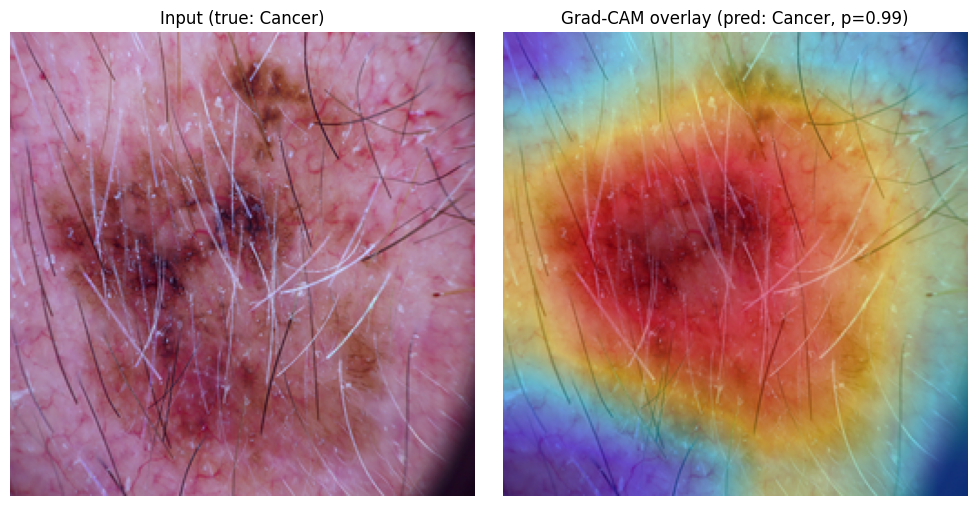

In [57]:
model = model.to(device)
model.eval()  # eval mode, but Grad-CAM still needs gradients (do NOT use torch.no_grad!)

# set your layer number and test image number here
layer_number = 3
test_image_number = 106

def get_target_layer(classifier):
    """Returns the last convolutional layer of the underlying feature extractor."""
    inner = classifier.model
    if isinstance(inner, SimpleConvNet):
        return inner.layers[layer_number]          # last Conv2d before the final MaxPool
    elif isinstance(inner, ResNet34Classifier):
        return inner.model.layer4[-1]   # last residual block of the final stage — standard Grad-CAM target for ResNets
    elif isinstance(inner, ResNet18Classifier):
        return inner.model.layer4[-1]
    else:
        raise ValueError(f'No target layer defined for model type: {type(inner)}')

target_layer = get_target_layer(model)
gradcam = GradCAMClassification(model, target_layer)

# FIXME: test set not defined yet, using validation set instead (see config above)
# grab a sample from the classification test set

def get_eval_transform(config):
    to_tensor = transforms.Lambda(lambda x: torch.from_numpy(x).permute(2, 0, 1).float() / 255.0)
    if config.get('pretrained_normalization', False):
        normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        return transforms.Compose([to_tensor, normalize])
    else:
        return transforms.Compose([to_tensor])
        
eval_transform = get_eval_transform(config)
test_ds = Scan_Dataset(os.path.join(data_dir, 'val'), transform=eval_transform)
image, label = test_ds[test_image_number]

x = image.unsqueeze(0).float().to(device)  # [1,C,H,W]

cam, prob = gradcam.compute_cam(x)
pred_label = int(prob > 0.5)

# original image for overlay (convert to HWC, uint8)
img_np = image.permute(1, 2, 0).cpu().numpy() if image.dim() == 3 else image.cpu().numpy()
img_np = np.uint8(255 * (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8))

heatmap = np.uint8(255 * cam)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_np)
ax[0].set_title(f'Input (true: {"Cancer" if label else "No cancer"})')
ax[0].axis('off')
ax[1].imshow(overlay)
ax[1].set_title(f'Grad-CAM overlay (pred: {"Cancer" if pred_label else "No cancer"}, p={prob:.2f})')
ax[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
model_hairaug = Classifier.load_from_checkpoint(saved_model_path)  # or your exact hairaug checkpoint path
model_hairaug = model_hairaug.to(device)
model_hairaug.eval()

eval_transform = get_eval_transform(config)  # pretrained_normalization=True
test_ds_for_hairaug = Scan_Dataset(os.path.join(data_dir, 'val'), transform=eval_transform, remove_hair_preprocessing=False)

compare_indices = [7, 249]
fig, axes = plt.subplots(len(compare_indices), 2, figsize=(10, 5*len(compare_indices)))

for row, idx in enumerate(compare_indices):
    img_orig, overlay, label, pred, prob = run_gradcam_for_comparison(model_hairaug, test_ds_for_hairaug, idx, device)
    axes[row, 0].imshow(img_orig)
    axes[row, 0].set_title(f'idx={idx} (true: {"Cancer" if label else "No cancer"})')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(f'Hair-augmented model\npred: {"Cancer" if pred else "No cancer"}, p={prob:.2f}')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# baseline (no synthetic hair) predictions, for reference
clean_tensor = predict_and_gradcam_on_array  # reuse same function, just pass raw_uint8 instead of synthetic_hairy

overlay_control_clean, prob_control_clean = predict_and_gradcam_on_array(model_control, raw_uint8, device, config)
overlay_hairaug_clean, prob_hairaug_clean = predict_and_gradcam_on_array(model_hairaug, raw_uint8, device, config)

print(f"True label: {'Cancer' if true_label else 'No cancer'}")
print(f"\n--- CLEAN image (no synthetic hair) ---")
print(f"Control:   p={prob_control_clean:.4f}, pred={'Cancer' if prob_control_clean>0.5 else 'No cancer'}")
print(f"Hair-aug:  p={prob_hairaug_clean:.4f}, pred={'Cancer' if prob_hairaug_clean>0.5 else 'No cancer'}")

print(f"\n--- WITH synthetic hair added ---")
print(f"Control:   p={prob_control:.4f}, pred={'Cancer' if prob_control>0.5 else 'No cancer'}")
print(f"Hair-aug:  p={prob_hairaug:.4f}, pred={'Cancer' if prob_hairaug>0.5 else 'No cancer'}")

print(f"\nControl flipped by synthetic hair: {(prob_control_clean>0.5) != (prob_control>0.5)}")
print(f"Hair-aug flipped by synthetic hair: {(prob_hairaug_clean>0.5) != (prob_hairaug>0.5)}")

## Understanding Grad-CAM

Below, intermediate results can be plotted, if needed, by completing the code.

In [ ]:
acts  = gradcam.activations.detach()            # [1,K,h,w] feature maps of the target layer
grads = gradcam.gradients.detach()              # [1,K,h,w] gradients w.r.t. those feature maps
weights = grads.mean(dim=(2, 3), keepdim=True)  # [1,K,1,1] one weight per channel (GAP over gradients)

raw_cam   = (weights * acts).sum(dim=1, keepdim=True)   # before ReLU, can be negative
relu_cam  = F.relu(raw_cam)                               # after ReLU
upsampled = F.interpolate(relu_cam, size=x.shape[2:], mode='bilinear', align_corners=False)

def normalize01(t):
    t = t.squeeze().cpu().numpy()
    t = t - t.min()
    return t / t.max() if t.max() > 0 else t

n_show = 8
top_channels = weights.squeeze().abs().argsort(descending=True)[:n_show].cpu().numpy()

# FIXME: complete code for plotting here

fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))

for i, ch in enumerate(top_channels):
    # individual channel's raw activation map (before weighting)
    channel_activation = acts[0, ch].detach().cpu().numpy()
    
    # this channel's contribution to the CAM (weight * activation), upsampled to input size
    channel_contribution = (weights[0, ch] * acts[0, ch]).unsqueeze(0).unsqueeze(0)
    channel_contribution = F.interpolate(channel_contribution, size=x.shape[2:], 
                                          mode='bilinear', align_corners=False)
    channel_contribution = normalize01(channel_contribution)
    
    # top row: raw activation map for this channel (small, feature-map resolution)
    axes[0, i].imshow(channel_activation, cmap='viridis')
    axes[0, i].set_title(f'Ch {ch}\nweight={weights.squeeze()[ch].item():.3f}')
    axes[0, i].axis('off')
    
    # bottom row: this channel's weighted contribution, upsampled and overlaid on the image
    axes[1, i].imshow(img_np)
    axes[1, i].imshow(channel_contribution, cmap='jet', alpha=0.5)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Raw activation\n(feature map res.)', fontsize=10)
axes[1, 0].set_ylabel('Weighted contribution\n(upsampled overlay)', fontsize=10)
plt.suptitle(f'Top {n_show} channels by |weight| — {config["experiment_name"]}')
plt.tight_layout()
plt.show()

# also show the final combined CAM for reference
final_cam = normalize01(upsampled)
fig2, ax2 = plt.subplots(1, 2, figsize=(10, 5))
ax2[0].imshow(img_np)
ax2[0].set_title('Input')
ax2[0].axis('off')
ax2[1].imshow(img_np)
ax2[1].imshow(final_cam, cmap='jet', alpha=0.5)
ax2[1].set_title('Combined Grad-CAM (all channels)')
ax2[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def run_gradcam_for_comparison(model, dataset, idx, device, title=""):
    model = model.to(device)
    model.eval()
    
    image, label = dataset[idx]
    x = image.unsqueeze(0).float().to(device)
    
    target_layer = get_target_layer(model)
    gradcam = GradCAMClassification(model, target_layer)
    cam, prob = gradcam.compute_cam(x)
    gradcam.remove_hooks()
    
    img_np = image.permute(1, 2, 0).cpu().numpy() if image.dim() == 3 else image.cpu().numpy()
    img_np = np.uint8(255 * (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8))
    
    heatmap = np.uint8(255 * cam)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)
    
    pred_label = int(prob > 0.5)
    return img_np, overlay, label, pred_label, prob


# run for both models, same images, side by side
compare_indices = [0, 249]

fig, axes = plt.subplots(len(compare_indices), 3, figsize=(15, 5*len(compare_indices)))

for row, idx in enumerate(compare_indices):
    # control model — needs test_ds WITHOUT hair removal
    img_orig, overlay_control, label, pred_control, prob_control = run_gradcam_for_comparison(
        model_control, test_ds, idx, device)
    
    # hair-removal model — needs test_ds_hairremoved WITH hair removal
    _, overlay_hairremoval, _, pred_hairremoval, prob_hairremoval = run_gradcam_for_comparison(
        model_hairremoval, test_ds_hairremoved, idx, device)
    
    axes[row, 0].imshow(img_orig)
    axes[row, 0].set_title(f'idx={idx} (true: {"Cancer" if label else "No cancer"})')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(overlay_control)
    axes[row, 1].set_title(f'Control (no removal)\npred: {"Cancer" if pred_control else "No cancer"}, p={prob_control:.2f}')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(overlay_hairremoval)
    axes[row, 2].set_title(f'Hair removed\npred: {"Cancer" if pred_hairremoval else "No cancer"}, p={prob_hairremoval:.2f}')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
low_hair_idx = 33
f = val_files[low_hair_idx]
raw = nib.load(f).get_fdata()
raw_uint8 = np.uint8(255 * (raw - raw.min()) / (raw.max() - raw.min() + 1e-8))
true_label = int(f.split('.')[0][-1])

# prepare each version
hair_removed_img, _ = remove_hair(raw_uint8)
hair_added_img = add_synthetic_hair(raw_uint8, n_hairs=8)

# run each model on its corresponding image
overlay_control, prob_control = predict_and_gradcam_full(model_control, raw_uint8, device, config, apply_hair_removal=False)
overlay_hairremoval, prob_hairremoval = predict_and_gradcam_full(model_hairremoval, raw_uint8, device, config, apply_hair_removal=True)
overlay_hairaug, prob_hairaug = predict_and_gradcam_full(model_hairaug, hair_added_img, device, config, apply_hair_removal=False)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(raw_uint8)
axes[0].set_title(f'True image (true: {"Cancer" if true_label else "No cancer"})')
axes[0].axis('off')

axes[1].imshow(overlay_control)
axes[1].set_title(f'Control\npred: {"Cancer" if prob_control>0.5 else "No cancer"}, p={prob_control:.2f}')
axes[1].axis('off')

axes[2].imshow(overlay_hairremoval)
axes[2].set_title(f'Hair removed\npred: {"Cancer" if prob_hairremoval>0.5 else "No cancer"}, p={prob_hairremoval:.2f}')
axes[2].axis('off')

axes[3].imshow(overlay_hairaug)
axes[3].set_title(f'Hair added\npred: {"Cancer" if prob_hairaug>0.5 else "No cancer"}, p={prob_hairaug:.2f}')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import glob

for split in ['train', 'val', 'test']:
    files = sorted(glob.glob(os.path.join(new_data_dir, split, 'img*.nii')))
    print(f"{split}: {len(files)} files")
    print(f"  first few: {[os.path.basename(f) for f in files[:3]]}")

### Conformal prediction (advanced)

The code below performs conformal prediction for you. It's open ended code to optionally further explore.
Note that the validation set is initially also used as test set, as this is not defined yet.

In [ ]:
# calibration set (val) and evaluation set (test) -- built directly, no Grad-CAM dependency
eval_transform = get_eval_transform(config)  # reuse the function from the Grad-CAM fix
val_ds  = Scan_Dataset(os.path.join(data_dir, 'val'),  transform=eval_transform)
test_ds = Scan_Dataset(os.path.join(data_dir, 'val'), transform=eval_transform)

prob_fn = lambda xi: torch.sigmoid(model(xi)).item()  # xi: [1,C,H,W] on `device`


def compute_nonconformity_scores(prob_fn, dataset):
    """prob_fn(x) -> P(class=1) for a single input x [1,C,H,W].
    Nonconformity score for the *true* class: 1 - P(true class)."""
    scores = []
    for idx in range(len(dataset)):
        img_i, label_i = dataset[idx]
        xi = img_i.unsqueeze(0).float().to(device)
        p1 = prob_fn(xi)
        p_true = p1 if int(label_i) == 1 else (1 - p1)
        scores.append(1 - p_true)
    return np.array(scores)


def conformal_threshold(calib_scores, alpha=0.05):
    """Split-conformal quantile of the calibration nonconformity scores.
    Using this as the threshold gives a finite-sample marginal coverage guarantee of
    >= 1 - alpha on exchangeable test data."""
    n = len(calib_scores)
    q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    return np.quantile(calib_scores, q_level, method='higher')


def conformal_prediction_set(p1, threshold):
    """Nonconformity if a candidate class were the true one: 1 - p1 for class 1, p1 for
    class 0. Include the class in the set if its nonconformity is within the threshold."""
    nonconformity = {1: 1 - p1, 0: p1}
    return [c for c, score in nonconformity.items() if score <= threshold]


alpha = 0.05
calib_scores = compute_nonconformity_scores(prob_fn, val_ds)
threshold = conformal_threshold(calib_scores, alpha=alpha)
print(f'Conformal threshold (alpha={alpha}): {threshold:.4f}')

conformal_results = []
for idx in range(len(test_ds)):
    img_i, label_i = test_ds[idx]
    xi = img_i.unsqueeze(0).float().to(device)
    p1 = prob_fn(xi)
    pred_set = conformal_prediction_set(p1, threshold)
    conformal_results.append({'idx': idx, 'label': int(label_i), 'p1': p1,
                               'pred_set': pred_set, 'set_size': len(pred_set),
                               'covered': int(label_i) in pred_set})

coverage      = np.mean([r['covered'] for r in conformal_results])
avg_set_size  = np.mean([r['set_size'] for r in conformal_results])
ambiguous     = [r for r in conformal_results if r['set_size'] != 1]

print(f'Empirical coverage on test set: {coverage:.3f} (target: {1 - alpha:.3f})')
print(f'Average prediction set size: {avg_set_size:.3f} (1.0 = fully confident, 2.0 = "don\'t know")')
print(f'{len(ambiguous)} / {len(conformal_results)} test images got an ambiguous prediction set '
      f'(size != 1) - these are worth a closer manual look.')

In [ ]:
def find_misclassified(model, dataset, device, max_examples=None):
    model = model.to(device)
    model.eval()
    
    misclassified = []
    for idx in range(len(dataset)):
        img_i, label_i = dataset[idx]
        xi = img_i.unsqueeze(0).float().to(device)
        p1 = torch.sigmoid(model(xi)).item()
        pred = int(p1 > 0.5)
        true = int(label_i)
        if pred != true:
            misclassified.append({'idx': idx, 'true': true, 'pred': pred, 'p': p1})
    
    print(f"{len(misclassified)} / {len(dataset)} misclassified")
    
    # split by error type
    false_negatives = [m for m in misclassified if m['true'] == 1]  # missed cancer
    false_positives = [m for m in misclassified if m['true'] == 0]  # false alarm
    print(f"  False negatives (missed cancer): {len(false_negatives)}")
    print(f"  False positives (false alarm): {len(false_positives)}")
    
    return misclassified, false_negatives, false_positives


def show_misclassified_grid(dataset, misclass_list, data_dir_split, n=8, title=""):
    """Shows the raw (unnormalized) images so you can actually see hair/artifacts clearly."""
    files = sorted(glob.glob(os.path.join(data_dir_split, 'img*.nii')))
    
    n = min(n, len(misclass_list))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    
    for i, m in enumerate(misclass_list[:n]):
        # load the RAW image (not the normalized tensor) for clear visual inspection
        raw_img = nib.load(files[m['idx']]).get_fdata()
        raw_img_display = np.uint8(255 * (raw_img - raw_img.min()) / (raw_img.max() - raw_img.min() + 1e-8))
        
        axes[i].imshow(raw_img_display)
        axes[i].set_title(f"idx={m['idx']}\ntrue={'Cancer' if m['true'] else 'No cancer'}\npred p={m['p']:.2f}")
        axes[i].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
misclassified, false_negatives, false_positives = find_misclassified(model, test_ds, device)

show_misclassified_grid(test_ds, false_negatives, os.path.join(data_dir, 'val'), n=8, title="False Negatives (missed cancer)")
show_misclassified_grid(test_ds, false_positives, os.path.join(data_dir, 'val'), n=8, title="False Positives (false alarms)")

In [ ]:
def show_misclassified_grid_wrapped(dataset, misclass_list, data_dir_split, cols=6, title=""):
    files = sorted(glob.glob(os.path.join(data_dir_split, 'img*.nii')))
    n = len(misclass_list)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = axes.flatten() if n > 1 else [axes]
    
    for i, m in enumerate(misclass_list):
        raw_img = nib.load(files[m['idx']]).get_fdata()
        raw_img_display = np.uint8(255 * (raw_img - raw_img.min()) / (raw_img.max() - raw_img.min() + 1e-8))
        axes[i].imshow(raw_img_display)
        axes[i].set_title(f"idx={m['idx']}, p={m['p']:.2f}", fontsize=9)
        axes[i].axis('off')
    
    # hide any unused subplot slots
    for j in range(n, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
show_misclassified_grid_wrapped(test_ds, false_negatives, os.path.join(data_dir, 'val'), cols=6, title="False Negatives (missed cancer) - ResNet18")
show_misclassified_grid_wrapped(test_ds, false_positives, os.path.join(data_dir, 'val'), cols=6, title="False Positives (false alarms) - ResNet18")

In [ ]:
sample_files = sorted(glob.glob(os.path.join(data_dir, 'train', 'img*.nii')))
raw = nib.load(sample_files[47]).get_fdata()
raw_uint8 = np.uint8(255 * (raw - raw.min()) / (raw.max() - raw.min() + 1e-8))

cleaned, mask = remove_hair(raw_uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(raw_uint8); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Detected hair mask'); axes[1].axis('off')
axes[2].imshow(cleaned); axes[2].set_title('Hair removed (inpainted)'); axes[2].axis('off')
plt.tight_layout()
plt.show()

## Metrics

In [53]:
model_baseline = Classifier.load_from_checkpoint('/kaggle/working/best_classifier_resnet18_baseline.ckpt')
model_baseline = model_baseline.to(device)
model_baseline.eval()

model_hairremoval = Classifier.load_from_checkpoint('/kaggle/working/best_classifier_resnet18_hairremoval.ckpt')
model_hairremoval = model_hairremoval.to(device)
model_hairremoval.eval()

model_hairaug = Classifier.load_from_checkpoint('/kaggle/working/best_classifier_resnet18_hairaug.ckpt')
model_hairaug = model_hairaug.to(device)
model_hairaug.eval()

Classifier(
  (model): ResNet18Classifier(
    (model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1):

Baseline: AUC = 0.8687
Hair removed: AUC = 0.8064
Hair augmented: AUC = 0.8896


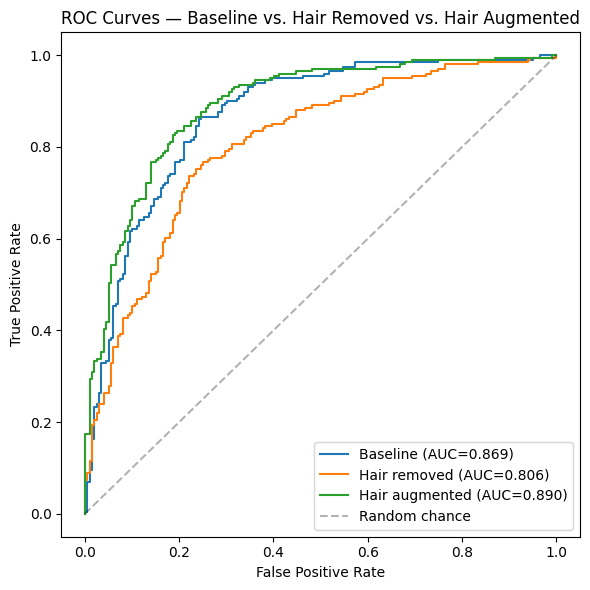

In [60]:
from sklearn.metrics import roc_auc_score, roc_curve

config['pretrained_normalization'] = True  # all three are resnet18 variants
eval_transform = get_eval_transform(config)

test_ds = Scan_Dataset(config['test_data_dir'], transform=eval_transform, remove_hair_preprocessing=False)
test_ds_hairremoved = Scan_Dataset(config['test_data_dir'], transform=eval_transform, remove_hair_preprocessing=True)

def compute_auc(model, dataset, device):
    model = model.to(device)
    model.eval()
    true_labels, probs = [], []
    for idx in range(len(dataset)):
        img_i, label_i = dataset[idx]
        xi = img_i.unsqueeze(0).float().to(device)
        p1 = torch.sigmoid(model(xi)).item()
        true_labels.append(int(label_i))
        probs.append(p1)
    auc = roc_auc_score(true_labels, probs)
    return auc, true_labels, probs

models_to_compare = {
    'Baseline':        (model_baseline,     test_ds),
    'Hair removed':    (model_hairremoval,  test_ds_hairremoved),
    'Hair augmented':  (model_hairaug,      test_ds),
}

results = {}
for name, (model, ds) in models_to_compare.items():
    auc, labels, probs = compute_auc(model, ds, device)
    results[name] = {'auc': auc, 'labels': labels, 'probs': probs}
    print(f"{name}: AUC = {auc:.4f}")

plt.figure(figsize=(6,6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})")
plt.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Baseline vs. Hair Removed vs. Hair Augmented')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/roc_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## Compare grad-cams

In [63]:
import pandas as pd
test_files = sorted(glob.glob(os.path.join(config['test_data_dir'], 'img*.nii')))

hair_amounts = []
for i, f in enumerate(test_files):
    raw = nib.load(f).get_fdata()
    raw_uint8 = np.uint8(255 * (raw - raw.min()) / (raw.max() - raw.min() + 1e-8))
    _, mask = remove_hair(raw_uint8)
    hair_pixel_count = np.sum(mask > 0)
    label = int(f.split('.')[0][-1])
    hair_amounts.append({'idx': i, 'file': os.path.basename(f), 'hair_pixels': hair_pixel_count, 'label': label})

hair_df_test = pd.DataFrame(hair_amounts).sort_values('hair_pixels', ascending=False)
print("Most hairy:")
print(hair_df_test.head(10))
print("\nLeast hairy:")
print(hair_df_test.tail(10))

Most hairy:
     idx            file  hair_pixels  label
101  101  img_0102_0.nii        43855      0
66    66  img_0067_1.nii        39507      1
394  394  img_1227_1.nii        37138      1
386  386  img_1215_1.nii        36928      1
278  278  img_1103_1.nii        36494      1
267  267  img_1092_0.nii        36385      0
152  152  img_0153_1.nii        36249      1
52    52  img_0053_1.nii        36073      1
272  272  img_1097_1.nii        36019      1
14    14  img_0015_1.nii        35918      1

Least hairy:
     idx            file  hair_pixels  label
71    71  img_0072_0.nii         4312      0
197  197  img_0198_0.nii         4306      0
153  153  img_0154_0.nii         3964      0
85    85  img_0086_0.nii         3943      0
331  331  img_1156_0.nii         3892      0
137  137  img_0138_0.nii         3774      0
343  343  img_1168_0.nii         3401      0
352  352  img_1177_1.nii         3306      1
371  371  img_1196_0.nii         2680      0
325  325  img_1150_0.nii     

In [65]:
def get_target_layer(classifier):
    inner = classifier.model
    if isinstance(inner, SimpleConvNet):
        return inner.layers[layer_number]
    elif isinstance(inner, ResNet34Classifier):
        return inner.model.layer4[-1]
    elif isinstance(inner, ResNet18Classifier):
        return inner.model.layer4[-1]
    else:
        raise ValueError(f'No target layer defined for model type: {type(inner)}')


def load_test_image(idx):
    raw = nib.load(test_files[idx]).get_fdata()
    return np.uint8(255 * (raw - raw.min()) / (raw.max() - raw.min() + 1e-8))


def predict_and_gradcam(model, image_array, device, config, apply_hair_removal=False):
    img_for_model = image_array.copy()
    if apply_hair_removal:
        img_for_model, _ = remove_hair(np.uint8(img_for_model))
    
    to_tensor = transforms.Lambda(lambda x: torch.from_numpy(x).permute(2,0,1).float()/255.0)
    if config.get('pretrained_normalization', False):
        normalize = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        tensor = normalize(to_tensor(img_for_model.astype(np.float64)))
    else:
        tensor = to_tensor(img_for_model.astype(np.float64))
    x = tensor.unsqueeze(0).float().to(device)
    
    target_layer = get_target_layer(model)
    gradcam = GradCAMClassification(model, target_layer)
    cam, prob = gradcam.compute_cam(x)
    gradcam.remove_hooks()
    
    heatmap = np.uint8(255 * cam)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(np.uint8(img_for_model), 0.6, heatmap_color, 0.4, 0)
    return overlay, prob

In [67]:
test_files = sorted(glob.glob(os.path.join(config['test_data_dir'], 'img*.nii')))

hairy_idx = 101
hairy_img = load_test_image(hairy_idx)
hairy_label = int(test_files[hairy_idx].split('.')[0][-1])

clean_idx = 325
clean_img = load_test_image(clean_idx)
clean_label = int(test_files[clean_idx].split('.')[0][-1])

stressed_img = add_synthetic_hair(clean_img, n_hairs=8)

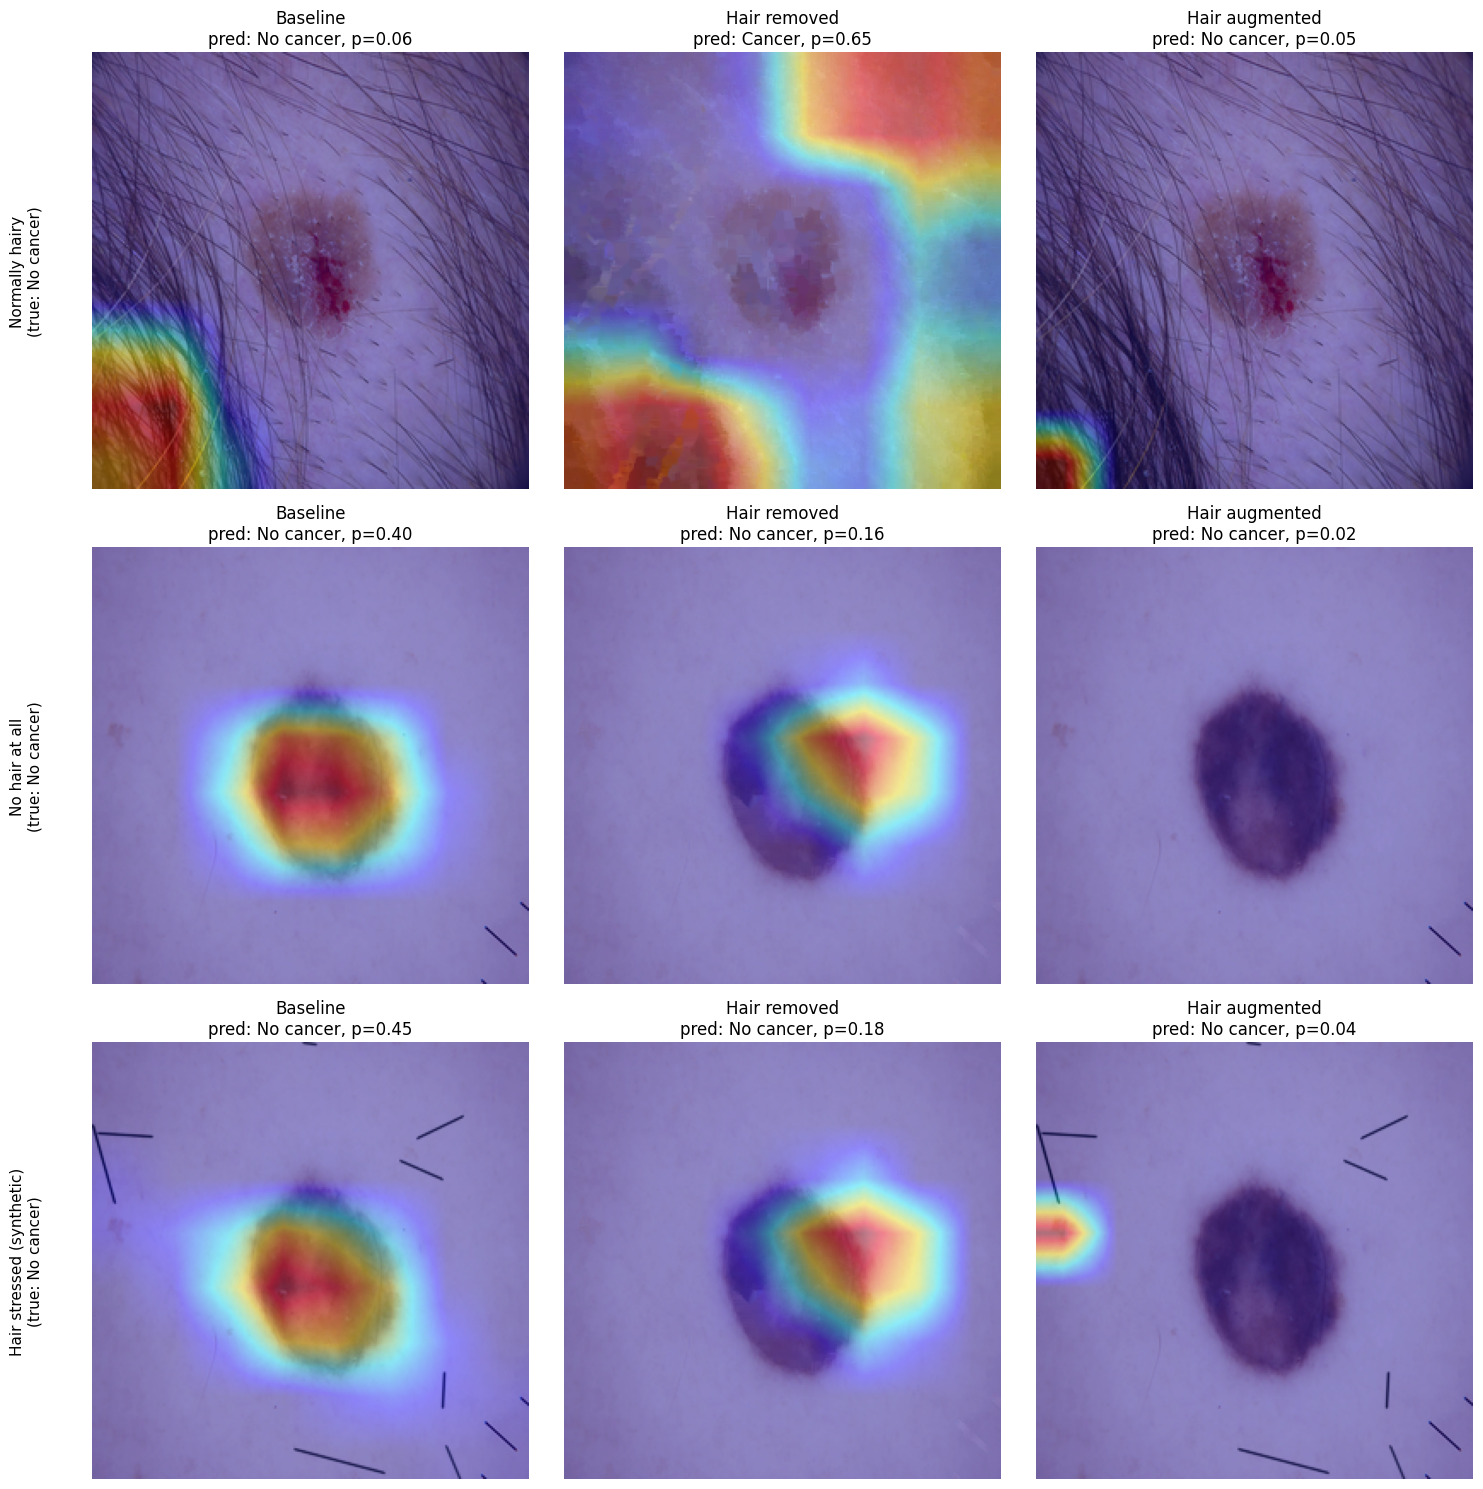

Saved — download this now.


In [68]:
image_variants = [
    ("Normally hairy", hairy_img, hairy_label),
    ("No hair at all", clean_img, clean_label),
    ("Hair stressed (synthetic)", stressed_img, clean_label),
]

models_ordered = [
    ("Baseline", model_baseline, False),
    ("Hair removed", model_hairremoval, True),
    ("Hair augmented", model_hairaug, False),
]

fig, axes = plt.subplots(len(image_variants), len(models_ordered), figsize=(15, 5*len(image_variants)))

for row, (variant_name, img, true_label) in enumerate(image_variants):
    for col, (model_name, model, apply_removal) in enumerate(models_ordered):
        overlay, prob = predict_and_gradcam(model, img, device, config, apply_hair_removal=apply_removal)
        axes[row, col].imshow(overlay)
        axes[row, col].set_title(f'{model_name}\npred: {"Cancer" if prob>0.5 else "No cancer"}, p={prob:.2f}')
        axes[row, col].axis('off')
    axes[row, 0].text(-0.15, 0.5, f'{variant_name}\n(true: {"Cancer" if true_label else "No cancer"})',
                       transform=axes[row, 0].transAxes, rotation=90, va='center', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_grid.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved — download this now.")